In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("ecommerce_customer_data_custom_ratios.csv")
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.00000,250000.000000,250000.000000,250000.000000,250000.000000,202404.000000,250000.000000,250000.000000
mean,25004.03624,254.659512,2.998896,2725.370732,43.940528,0.497861,43.940528,0.199496
std,14428.27959,141.568577,1.414694,1442.933565,15.350246,0.499997,15.350246,0.399622
min,1.00000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.000000
25%,12497.75000,132.000000,2.000000,1477.000000,31.000000,0.000000,31.000000,0.000000
50%,25018.00000,255.000000,3.000000,2724.000000,44.000000,0.000000,44.000000,0.000000
75%,37506.00000,377.000000,4.000000,3974.000000,57.000000,1.000000,57.000000,0.000000
max,50000.00000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.000000


In [4]:
df = df.dropna()

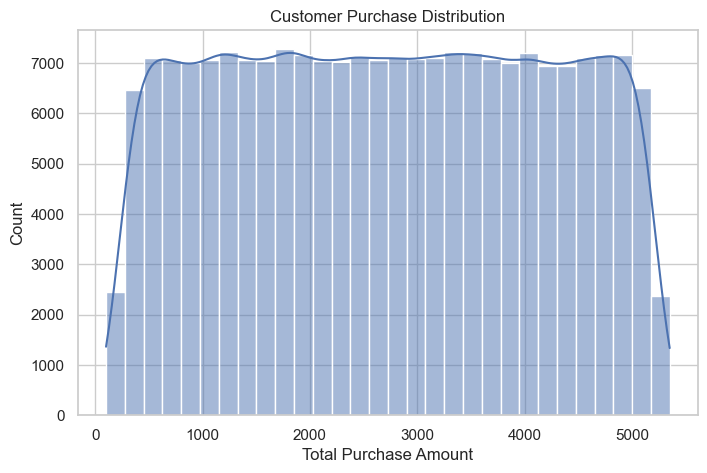

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['Total Purchase Amount'], bins=30, kde=True)
plt.title("Customer Purchase Distribution")
plt.show()

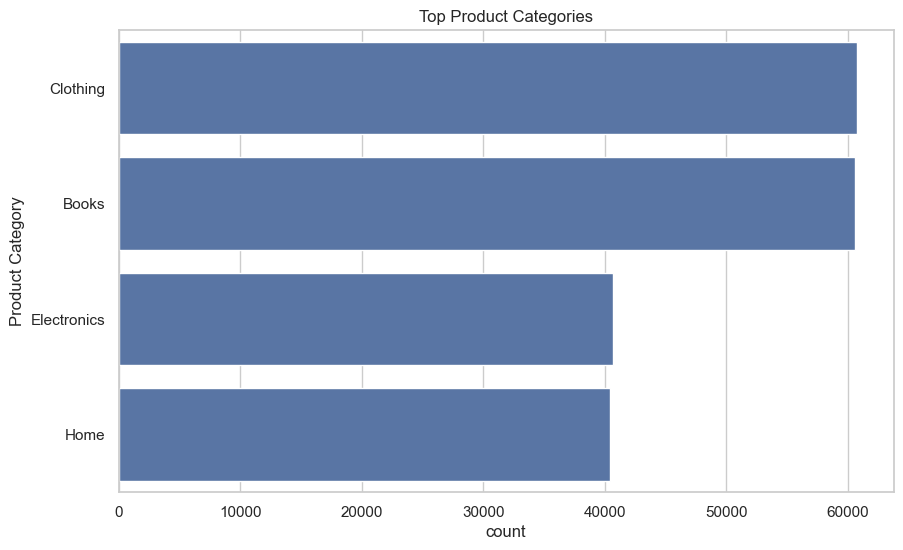

In [8]:
plt.figure(figsize=(10,6))
sns.countplot(y=df['Product Category'], order=df['Product Category'].value_counts().index)
plt.title("Top Product Categories")
plt.show()

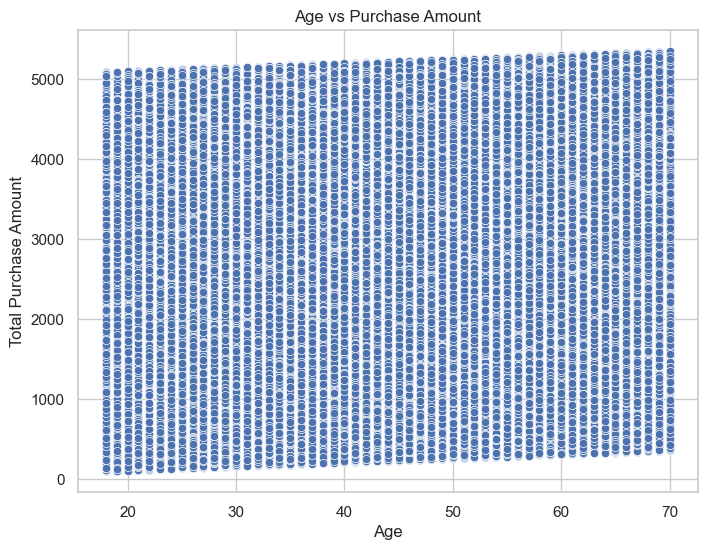

In [9]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Age', y='Total Purchase Amount', data=df)
plt.title("Age vs Purchase Amount")
plt.show()

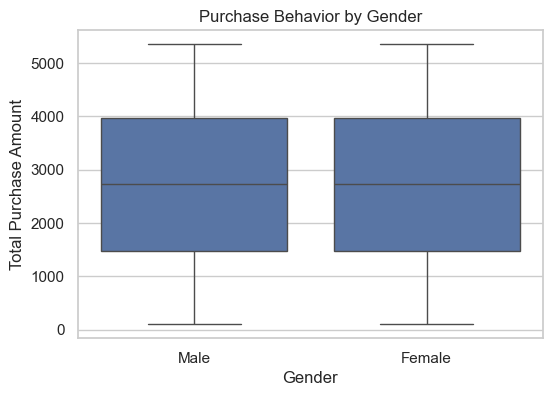

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Gender', y='Total Purchase Amount', data=df)
plt.title("Purchase Behavior by Gender")
plt.show()

In [12]:
from sklearn.cluster import KMeans

In [13]:
X = df[['Age','Total Purchase Amount']]

In [14]:
kmeans = KMeans(n_clusters=4)
df['Cluster'] = kmeans.fit_predict(X)

C:\Users\anish\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


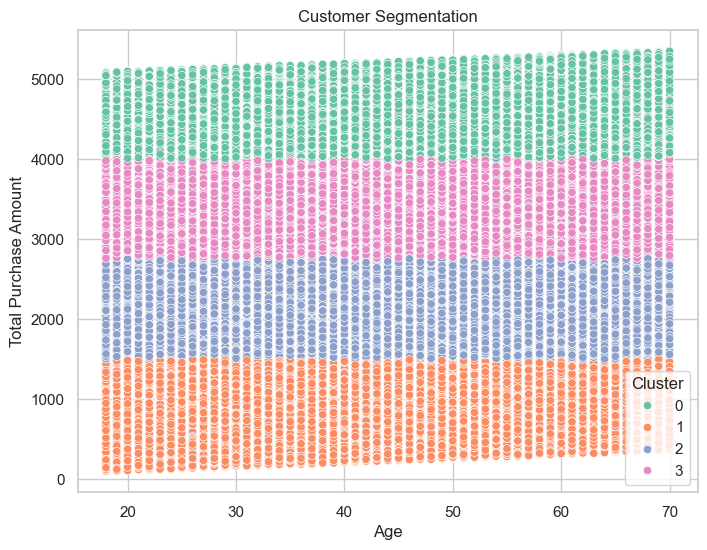

In [15]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Age', y='Total Purchase Amount', hue='Cluster', data=df, palette='Set2')
plt.title("Customer Segmentation")
plt.show()

In [17]:
df.columns


Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn', 'Cluster',
       'Date'],
      dtype='object')

In [18]:
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'], errors='coerce')

In [19]:
df['Month'] = df['Purchase Date'].dt.month

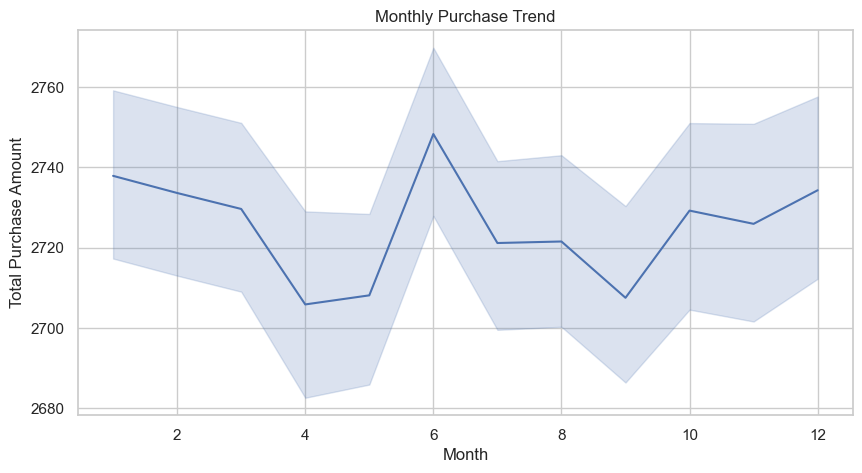

In [20]:
plt.figure(figsize=(10,5))
sns.lineplot(x='Month', y='Total Purchase Amount', data=df)
plt.title("Monthly Purchase Trend")
plt.xlabel("Month")
plt.ylabel("Total Purchase Amount")
plt.show()

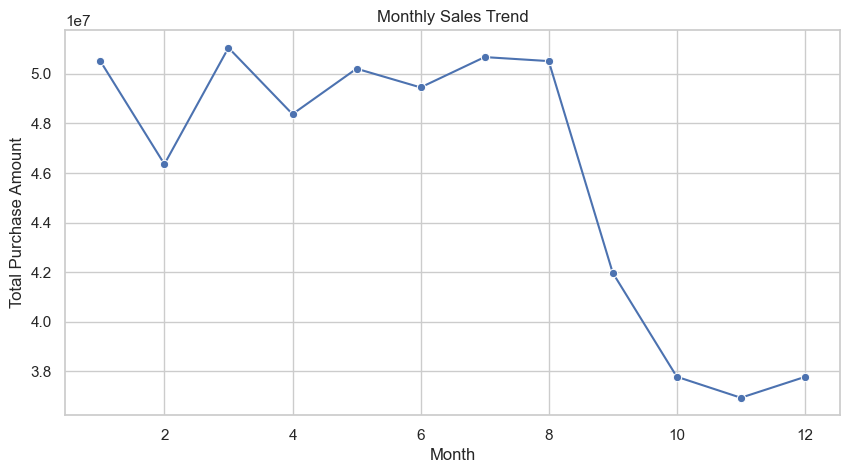

In [21]:
monthly_sales = df.groupby('Month')['Total Purchase Amount'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_sales, x='Month', y='Total Purchase Amount', marker='o')
plt.title("Monthly Sales Trend")
plt.show()

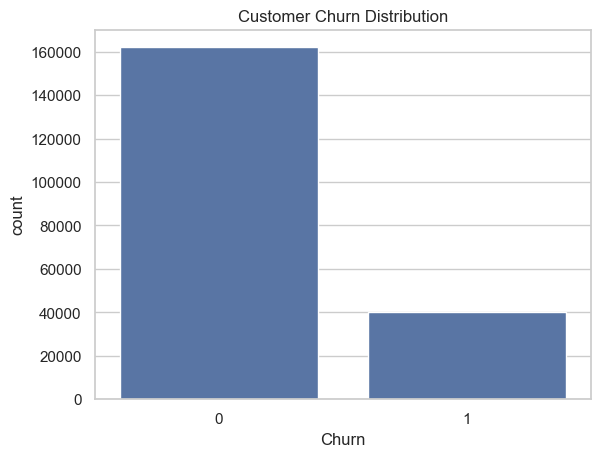

In [22]:
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

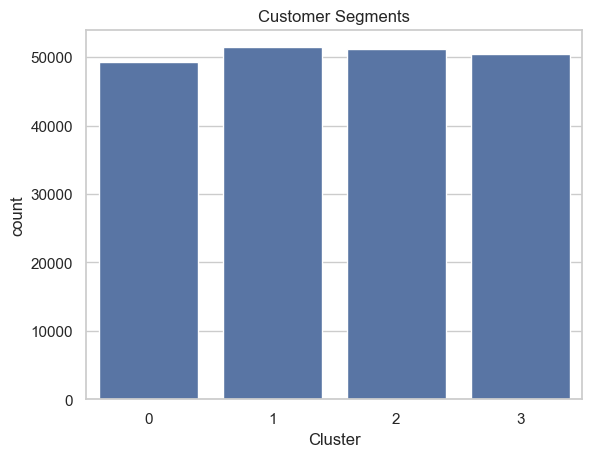

In [23]:
sns.countplot(x='Cluster', data=df)
plt.title("Customer Segments")
plt.show()

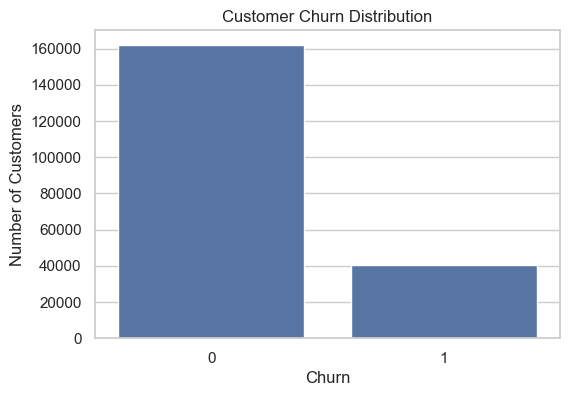

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [26]:
purchase_count = df.groupby('Customer ID').size()

In [27]:
df['Repeat_Customer'] = df['Customer ID'].map(purchase_count) > 1

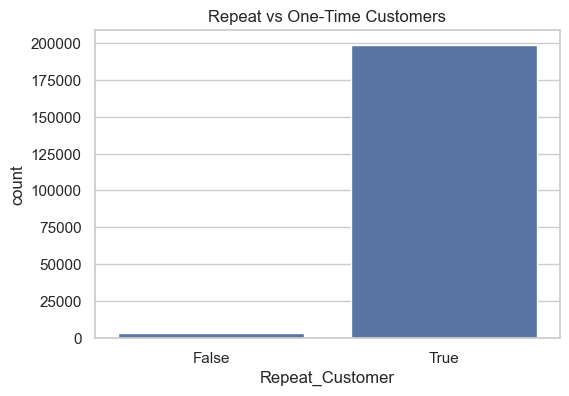

In [28]:
plt.figure(figsize=(6,4))
sns.countplot(x='Repeat_Customer', data=df)
plt.title("Repeat vs One-Time Customers")
plt.show()

In [ ]:
pair_df = df[['Age','Product Price','Quantity','Total Purchase Amount','Gender']]

In [ ]:
sns.pairplot(pair_df, hue='Gender')
plt.show()

In [ ]:
pair_df = df[['Age','Product Price','Quantity','Total Purchase Amount','Cluster']]

sns.pairplot(pair_df, hue='Cluster', palette='Set2')
plt.show()

In [ ]:
sns.pairplot(
    df[['Age','Product Price','Quantity','Total Purchase Amount','Cluster']],
    hue='Cluster',
    palette='coolwarm',
    diag_kind='kde'
)
plt.show()

In [ ]:
df = df.dropna()

In [ ]:
# Remove missing values
df = df.dropna()

# Convert purchase date to datetime
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'], errors='coerce')

# Extract Month for trend analysis
df['Month'] = df['Purchase Date'].dt.month

# Create Repeat Customer column
purchase_count = df.groupby('Customer ID').size()
df['Repeat_Customer'] = df['Customer ID'].map(purchase_count) > 1

In [ ]:
df.head()

In [ ]:
print(df.info())

In [ ]:
df.to_csv("cleaned_customer_behavior.csv", index=False)

Customer Behavior Analysis

InternSpark Data Analyst Internship Task

This project analyzes customer purchasing behavior to identify patterns,
customer segments, and churn risks using Python, Pandas, and Seaborn.

Key Insights

• Customers aged 25–40 contribute the highest purchase amounts.
• Electronics and clothing are the most purchased product categories.
• Female customers show slightly higher purchase frequency.
• Cluster analysis reveals a high-value customer segment.
• Monthly trends indicate increased purchases during mid-year months.

In [ ]:
Business Recommendations

1. Target high-value clusters with loyalty programs.
2. Offer personalized discounts for churn-risk customers.
3. Promote top-performing product categories.
4. Improve engagement through targeted marketing campaigns.
5. Encourage repeat purchases through reward systems.